<a href="https://colab.research.google.com/github/Koushal8-8/Heart-Disease-Machine-Learning-model-/blob/model.ipynb/Heart_Disease_prediction_model_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing required libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
#Linear Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer,KNNImputer,MissingIndicator
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
#for confusion matrix
from sklearn.metrics import confusion_matrix
#Random Forest
from sklearn.ensemble import RandomForestClassifier
#XGBoost
from xgboost import XGBClassifier


#Loading the data set

In [ ]:
pip install ucimlrepo


In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

# metadata
print(heart_disease.metadata)

# variable information
print(heart_disease.variables)


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [ ]:
df = pd.concat([X, y], axis=1)

In [ ]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1


In [ ]:
# there is 303 samples and 14 columns
df.shape

(303, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


there is missing values in the 11 and 12 column

to resolve the missing values

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


using SimpleImputer from sklearn.impute
(alternatives: KNNImputer)

In [ ]:
# using MissingIndicator to visualize the missing values
indicator = MissingIndicator(missing_values=np.nan, features='all')
indicator_mask = indicator.fit_transform(df)
indicator_mask = pd.DataFrame(indicator_mask, columns=df.columns)

In [ ]:
indicator_mask

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,False,False,False,False,False,False,False,False,False,False,False,False,False,False
299,False,False,False,False,False,False,False,False,False,False,False,False,False,False
300,False,False,False,False,False,False,False,False,False,False,False,False,False,False
301,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
imputer = SimpleImputer(strategy='median')
imputed_data = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)



In [ ]:
imputed_data


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1.0
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2.0
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3.0
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1.0


In [ ]:
df = imputed_data

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
df['num'].value_counts()

,count
num,
0.0,164
1.0,55
2.0,36
3.0,35
4.0,13


the target feature has multiple classes, therefore should be converted into binary.

In [ ]:
df['target'] = (df['num'] > 0).astype(int)

after converting the target label classes into binary format

In [ ]:
df['target'].value_counts()

,count
target,
0,164
1,139


where,

0 -> defective heart
1 -> healthy heart

about the features



1.  age → Age of the patient (in years)
2. sex → Gender
  0 = Female
  1 = Male
3. cp (chest pain type) → Type of chest pain
  0 = Typical angina
  1 = Atypical angina
  2 = Non-anginal pain
  3 = Asymptomatic
4. trestbps (resting blood pressure) → Blood pressure at rest (in mm Hg)
5. chol (cholesterol) → Serum cholesterol (in mg/dl)
6. fbs (fasting blood sugar) →
  1 = > 120 mg/dl
  0 = ≤ 120 mg/dl
7. restecg (resting ECG results) →
  0 = Normal
  1 = ST-T wave abnormality
  2 = Left ventricular hypertrophy
8. thalach (maximum heart rate achieved) → Maximum heart rate during test
9. exang (exercise induced angina) →
  1 = Yes
  0 = No
10. oldpeak → ST depression (difference in ECG readings during exercise vs rest)
11. slope → Slope of peak exercise ST segment
  0 = Upsloping
  1 = Flat
  2 = Downsloping
12. ca → Number of major vessels (0–3) colored by fluoroscopy
13. thal → Thalassemia (blood disorder test result)
  1 = Normal
  2 = Fixed defect
  3 = Reversible defect

and finally
14. num → expected output(target value)


In [ ]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0


In [ ]:
y

,num
0,0
1,2
2,1
3,0
4,0
...,...
298,1
299,2
300,3
301,1


# **visualization**

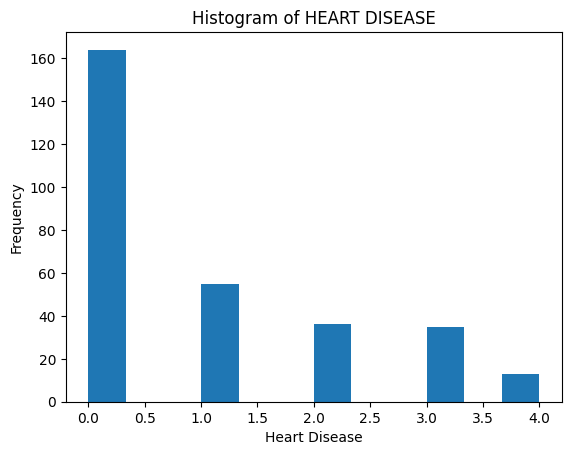

In [ ]:
plt.figure()
plt.hist(df['num'],bins=12)
plt.xlabel('Heart Disease')
plt.ylabel('Frequency')
plt.title('Histogram of HEART DISEASE')
plt.show()

Histogram

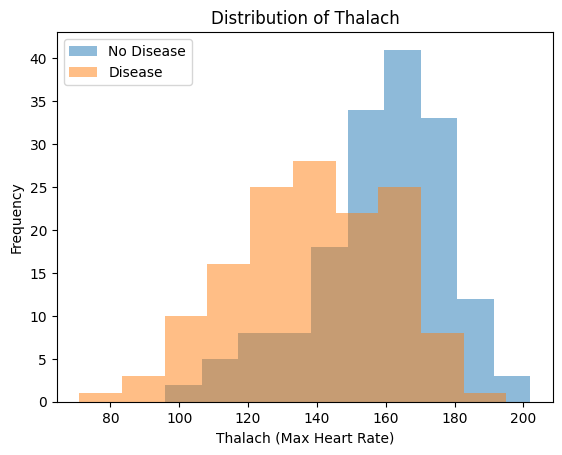

-------------------------------------------------------------------------


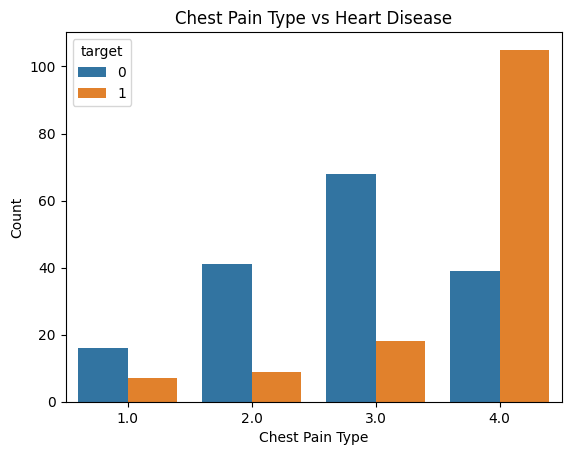

In [ ]:
plt.hist(df[df['target']==0]['thalach'], alpha=0.5, label='No Disease')
plt.hist(df[df['target']==1]['thalach'], alpha=0.5, label='Disease')

plt.xlabel("Thalach (Max Heart Rate)")
plt.ylabel("Frequency")
plt.title("Distribution of Thalach")
plt.legend()
plt.show()

print("-------------------------------------------------------------------------")

sns.countplot(x='cp', hue='target', data=df)

plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

Box Plot

/tmp/ipykernel_655/23843581.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


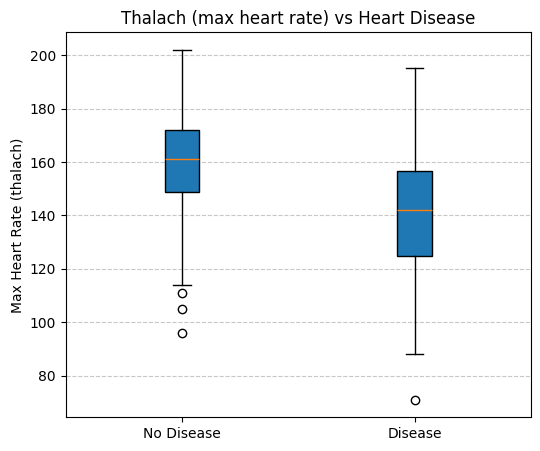

-------------------------------------------------------------------------


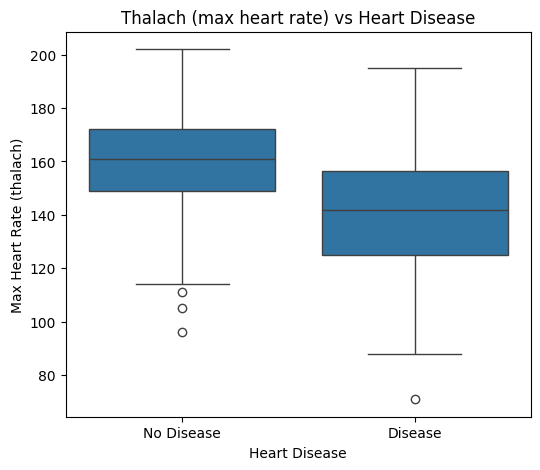

-------------------------------------------------------------------------


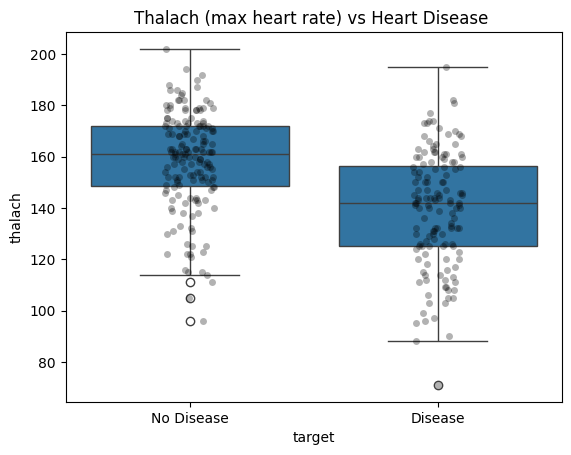

In [ ]:
plt.figure(figsize=(6,5))

plt.boxplot(
    [df[df['target']==0]['thalach'],
     df[df['target']==1]['thalach']],
    patch_artist=True,
    labels=['No Disease', 'Disease']
)

plt.ylabel("Max Heart Rate (thalach)")
plt.title("Thalach (max heart rate) vs Heart Disease")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

print("-------------------------------------------------------------------------")
plt.figure(figsize=(6,5))

sns.boxplot(x='target', y='thalach', data=df)

plt.xticks([0,1], ['No Disease', 'Disease'])
plt.xlabel("Heart Disease")
plt.ylabel("Max Heart Rate (thalach)")
plt.title("Thalach (max heart rate) vs Heart Disease")

plt.show()
print("-------------------------------------------------------------------------")
sns.boxplot(x='target', y='thalach', data=df)
sns.stripplot(x='target', y='thalach', data=df, color='black', alpha=0.3)

plt.xticks([0,1], ['No Disease', 'Disease'])
plt.title("Thalach (max heart rate) vs Heart Disease ")
plt.show()

meaning that people having lower heart rate usually have heart diseases.
here people with higher median max heart rate of 160 don't usually have heart disease.
people with median max heart rate of 140 have risk of heart disease.

Scatter plot

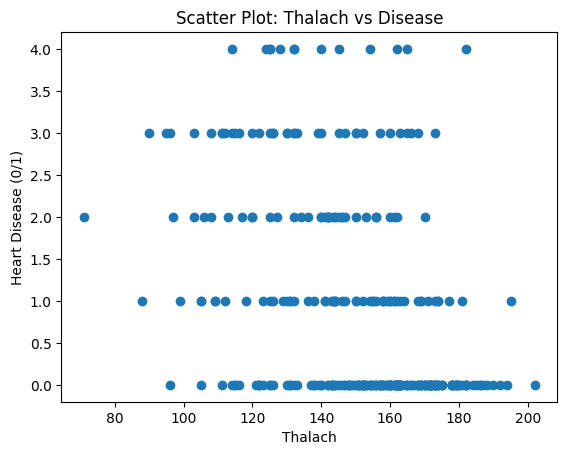

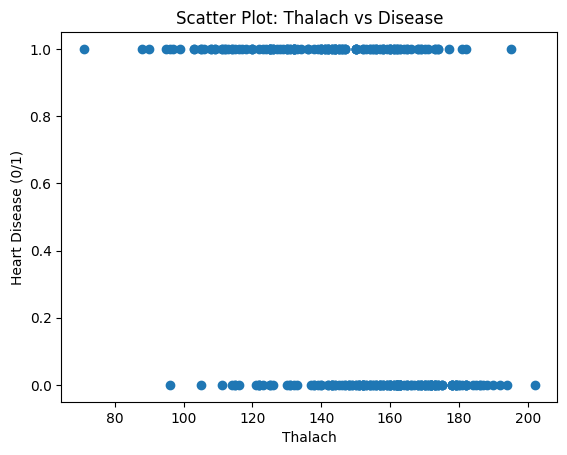

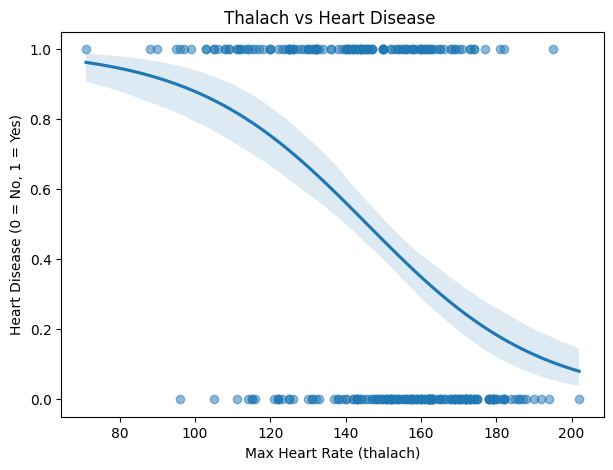

In [ ]:
plt.scatter(df['thalach'], df['num'])

plt.xlabel("Thalach")
plt.ylabel("Heart Disease (0/1)")
plt.title("Scatter Plot: Thalach vs Disease")
plt.show()

plt.scatter(df['thalach'], df['target'])

plt.xlabel("Thalach")
plt.ylabel("Heart Disease (0/1)")
plt.title("Scatter Plot: Thalach vs Disease")
plt.show()

plt.figure(figsize=(7,5))

sns.regplot(
    x='thalach',
    y='target',
    data=df,
    logistic=True,
    scatter_kws={'alpha':0.5}
)

plt.xlabel("Max Heart Rate (thalach)")
plt.ylabel("Heart Disease (0 = No, 1 = Yes)")
plt.title("Thalach vs Heart Disease ")

plt.show()

Bar plot

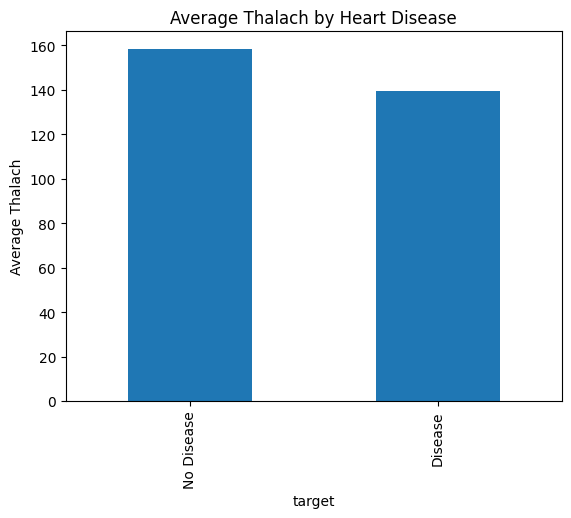

In [ ]:
df.groupby('target')['thalach'].mean().plot(kind='bar')

plt.xticks([0,1], ['No Disease','Disease'])
plt.ylabel("Average Thalach")
plt.title("Average Thalach by Heart Disease")
plt.show()

meaning heart rate with average of 160 usually don't have risk of heart disease
and average of 140 have the risk of heart related problems

Age vs Heart Disease

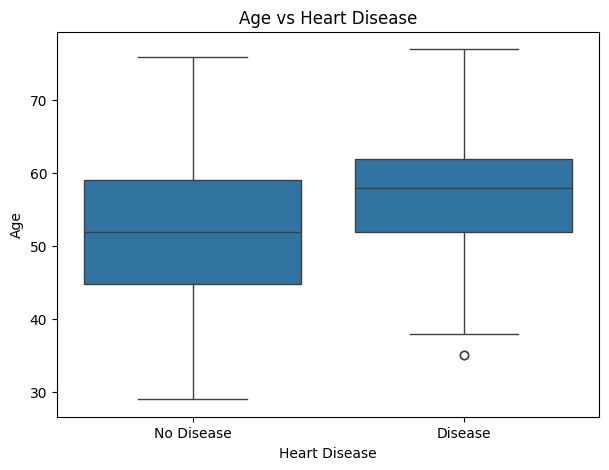

In [ ]:

plt.figure(figsize=(7,5))

sns.boxplot(x='target', y='age', data=df)

plt.xticks([0,1], ['No Disease', 'Disease'])
plt.xlabel("Heart Disease")
plt.ylabel("Age")
plt.title("Age vs Heart Disease")

plt.show()

Blood Pressure vs Heart Disease

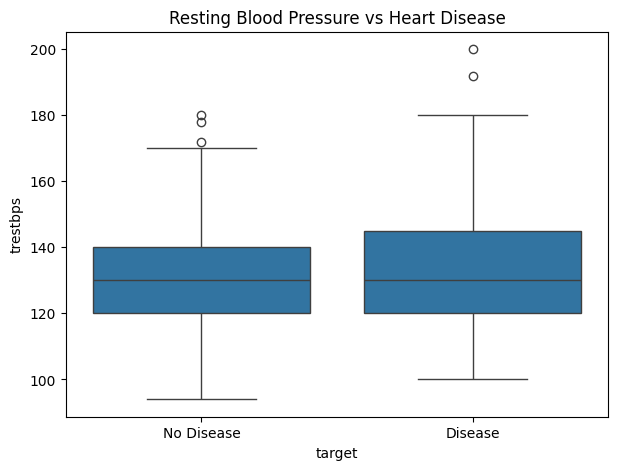

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(x='target', y='trestbps', data=df)

plt.xticks([0,1], ['No Disease', 'Disease'])
plt.title("Resting Blood Pressure vs Heart Disease")

plt.show()

Cholesterol vs Heart Disease

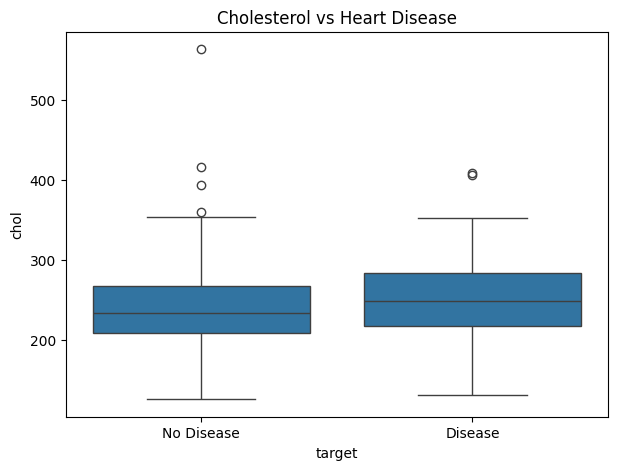

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(x='target', y='chol', data=df)

plt.xticks([0,1], ['No Disease', 'Disease'])
plt.title("Cholesterol vs Heart Disease")

plt.show()

more risk of heart disease with increase in person's age, blood pressure and cholesterol

### Feature Engineering: Creating `thalach_age_ratio`

We'll create a new feature by dividing `thalach` (maximum heart rate achieved) by `age`. This new ratio might provide more predictive power by normalizing the maximum heart rate by the patient's age.

In [ ]:
df['thalach_age_ratio'] = df['thalach'] / df['age']

print("New feature 'thalach_age_ratio' created. Here are the first 5 rows:")
display(df[['thalach', 'age', 'thalach_age_ratio', 'target']].head())

New feature 'thalach_age_ratio' created. Here are the first 5 rows:


,thalach,age,thalach_age_ratio,target
0,150.0,63.0,2.380952,0
1,108.0,67.0,1.611940,1
2,129.0,67.0,1.925373,1
3,187.0,37.0,5.054054,0
4,172.0,41.0,4.195122,0


### Visualization of `thalach_age_ratio`

Let's visualize the distribution of this new feature for both target classes (heart disease vs. no heart disease) to see if it shows any clear separation.

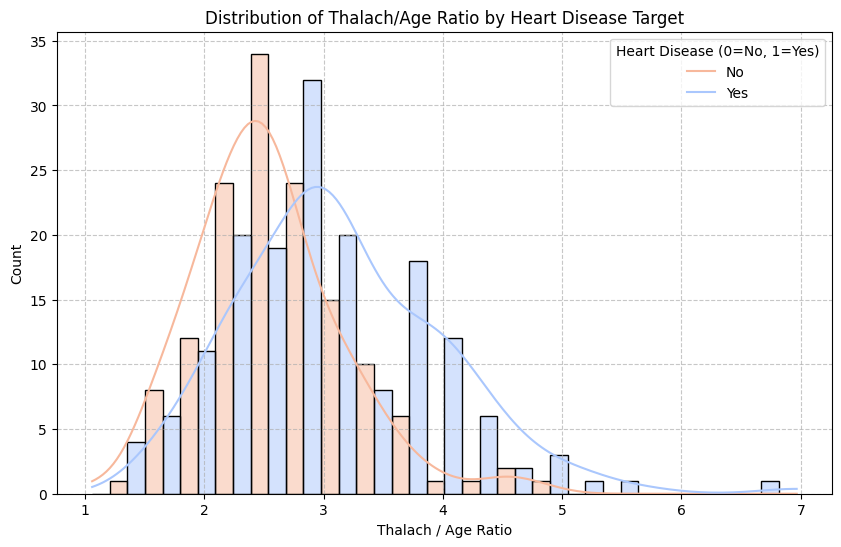

/tmp/ipykernel_655/3702899924.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='thalach_age_ratio', data=df, palette='coolwarm')


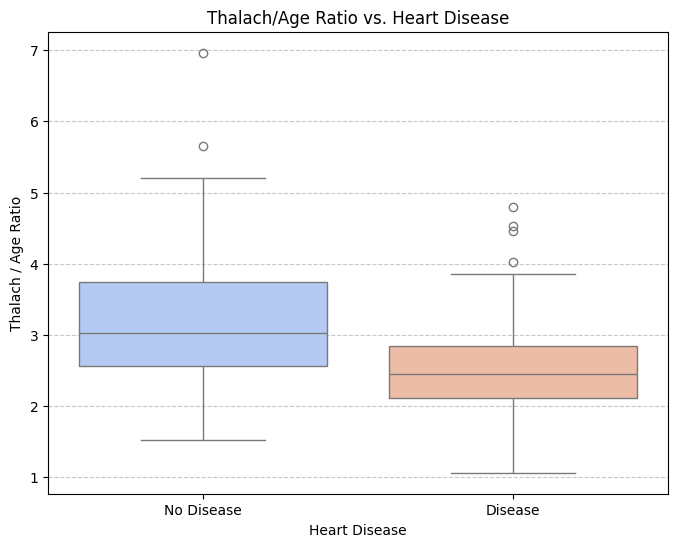

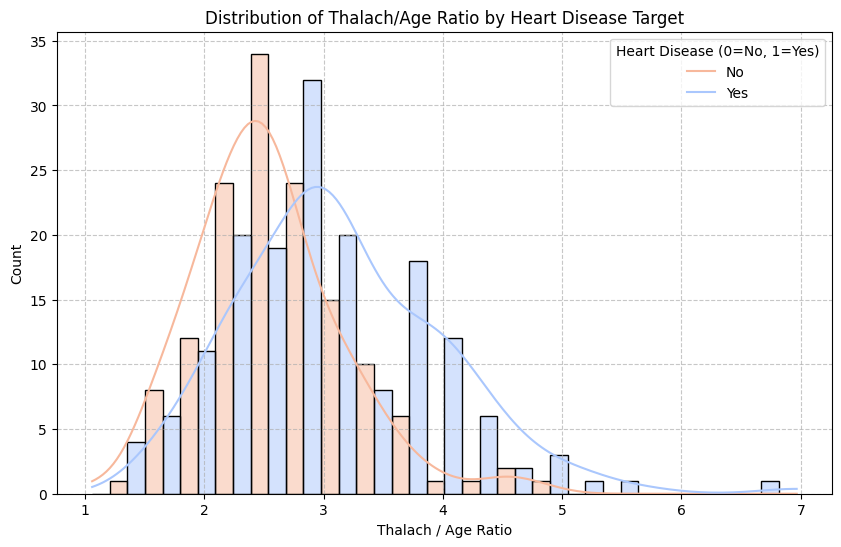

/tmp/ipykernel_655/3702899924.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='thalach_age_ratio', data=df, palette='coolwarm')


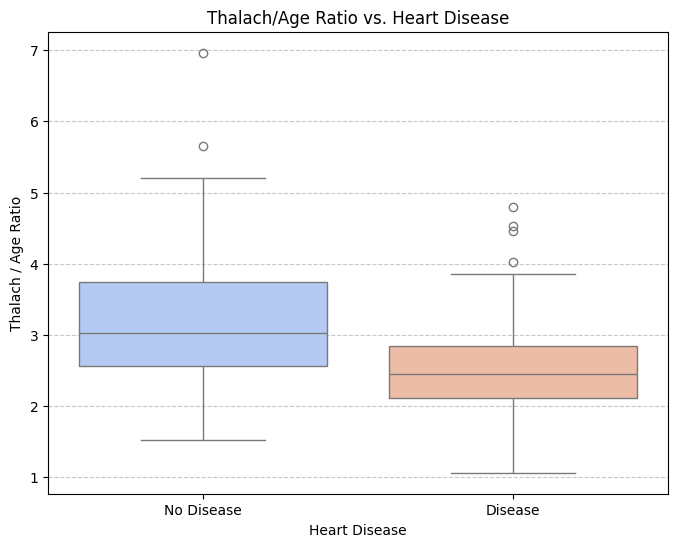

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='thalach_age_ratio', hue='target', multiple='dodge', bins=20, kde=True, palette='coolwarm')
plt.title('Distribution of Thalach/Age Ratio by Heart Disease Target')
plt.xlabel('Thalach / Age Ratio')
plt.ylabel('Count')
plt.legend(title='Heart Disease (0=No, 1=Yes)', labels=['No', 'Yes'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x='target', y='thalach_age_ratio', data=df, palette='coolwarm')
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.title('Thalach/Age Ratio vs. Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Thalach / Age Ratio')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**#####**

Absolute Feature correlations with target (descending order):
 thal                 0.522057
ca                   0.460033
exang                0.431894
oldpeak              0.424510
thalach              0.417167
cp                   0.414446
thalach_age_ratio    0.379745
slope                0.339213
sex                  0.276816
age                  0.223120
restecg              0.169202
trestbps             0.150825
chol                 0.085164
fbs                  0.025264
dtype: float64

Selected top 6 features by correlation with target: ['thal', 'ca', 'exang', 'oldpeak', 'thalach', 'cp']


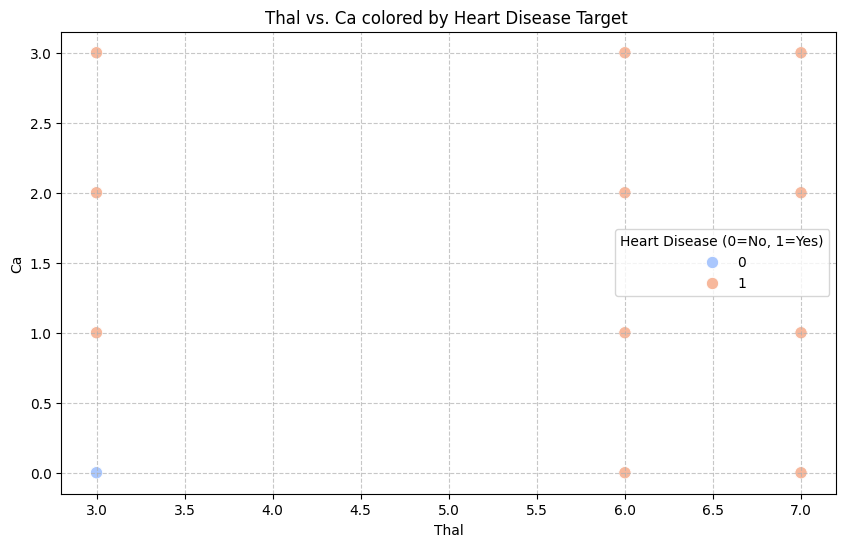

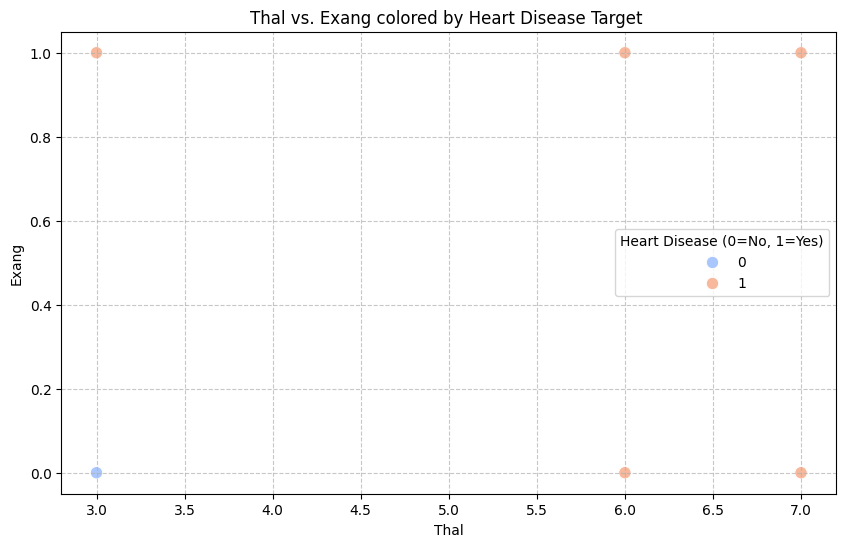

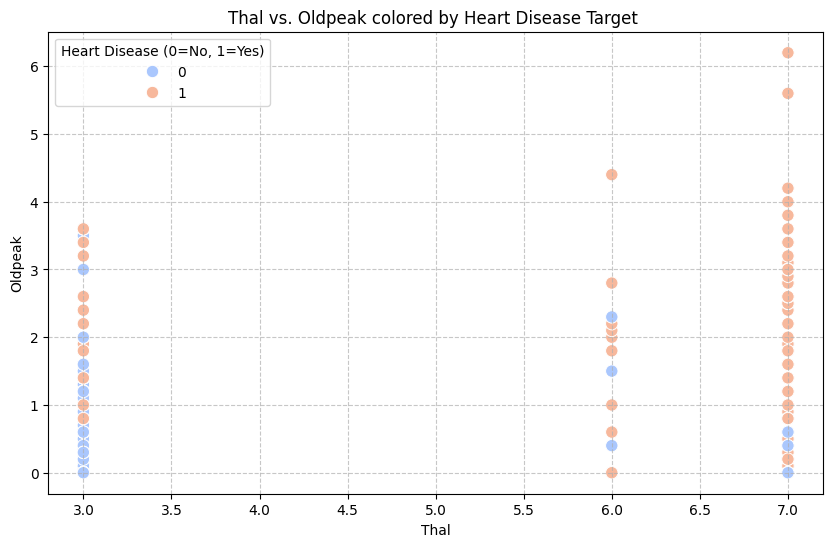

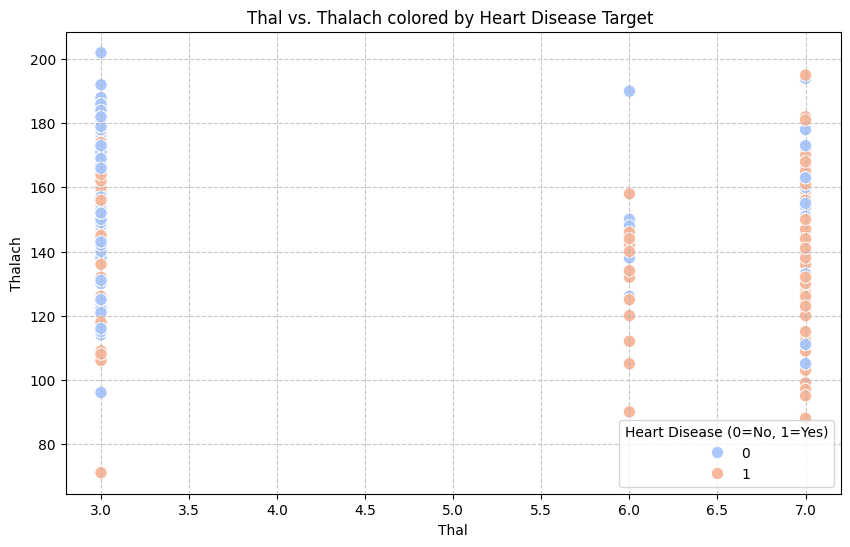

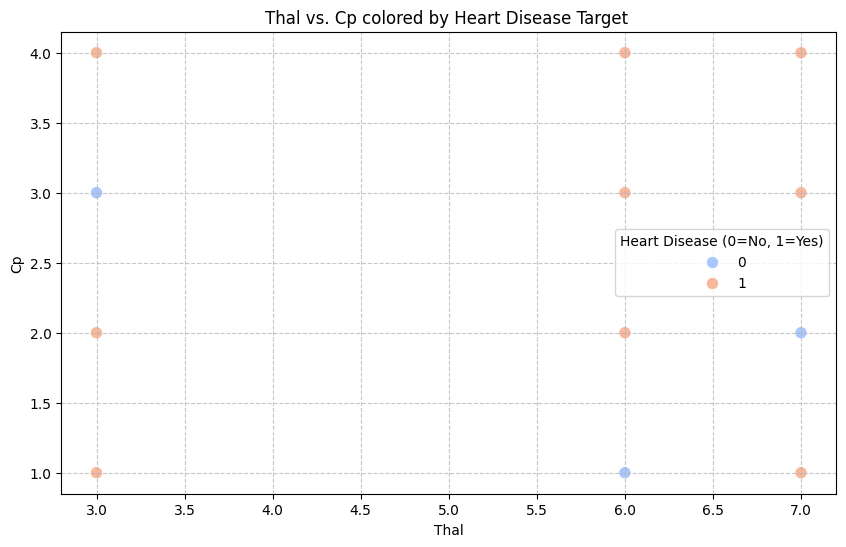

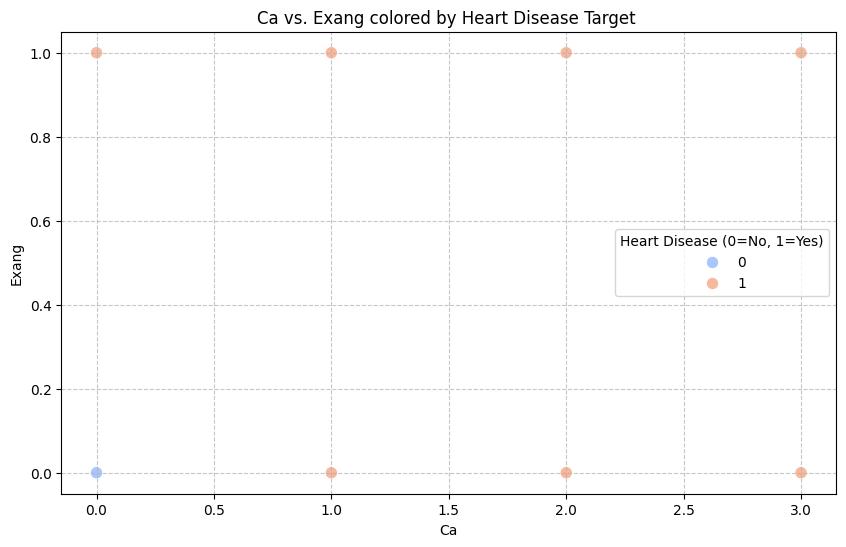

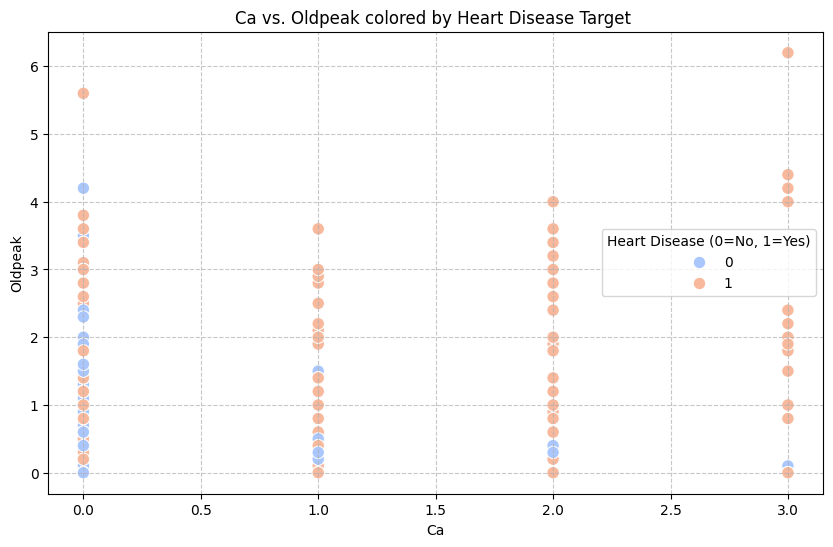

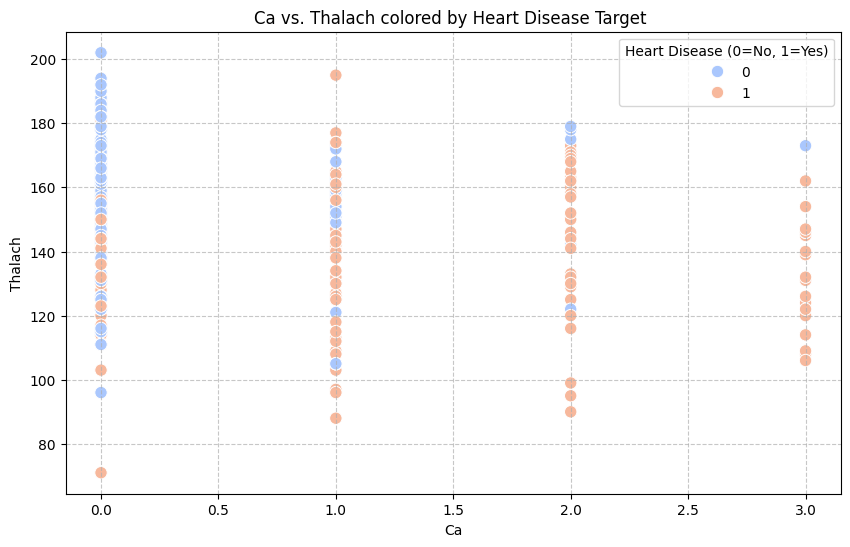

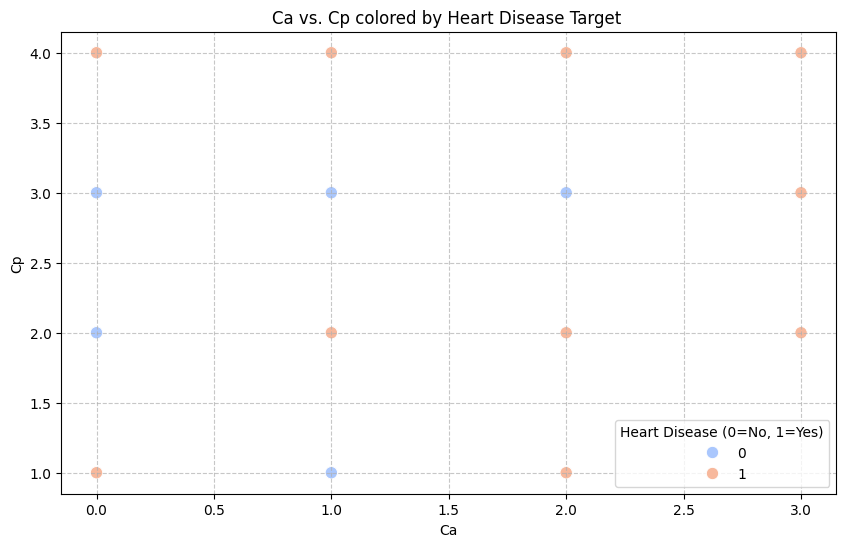

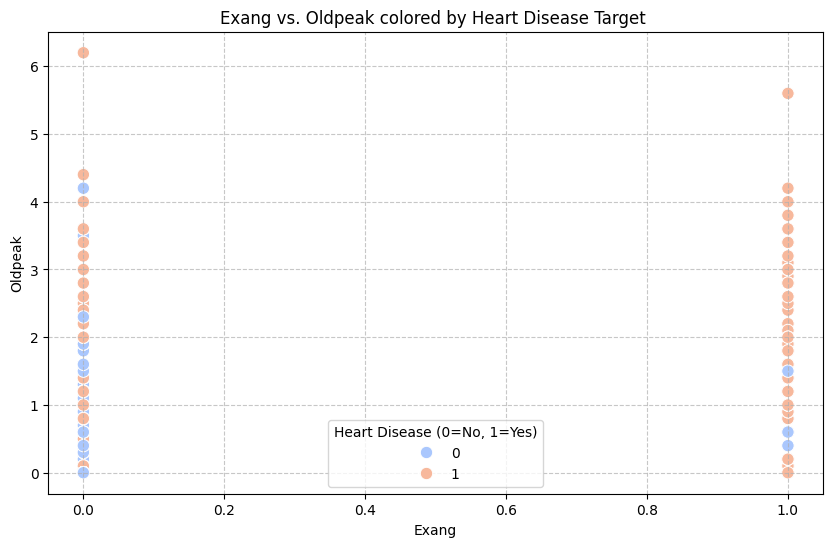

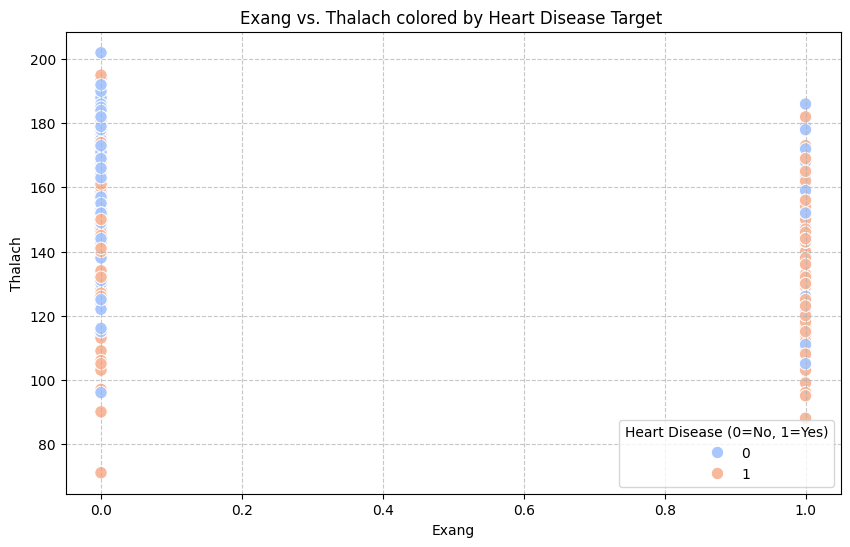

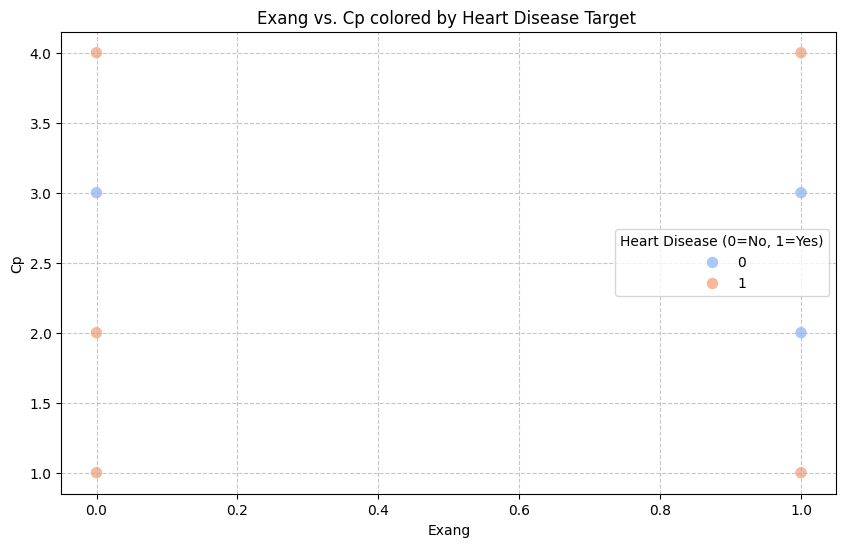

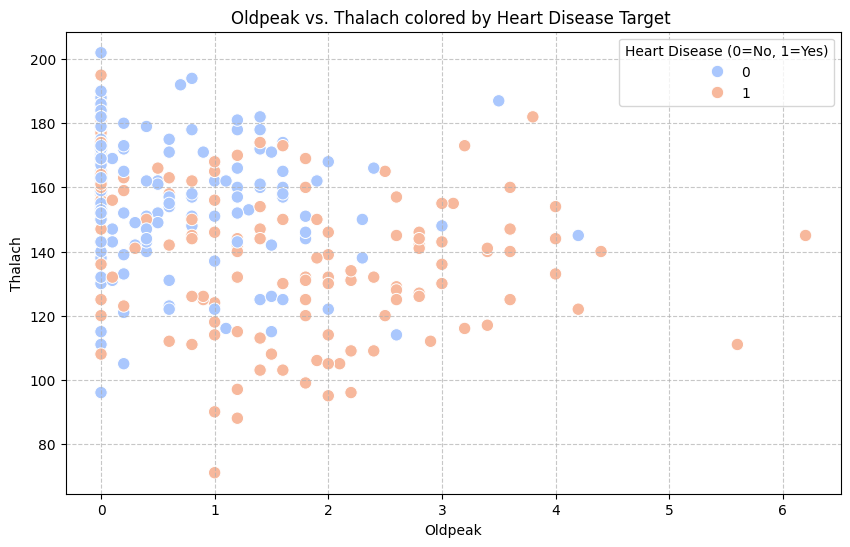

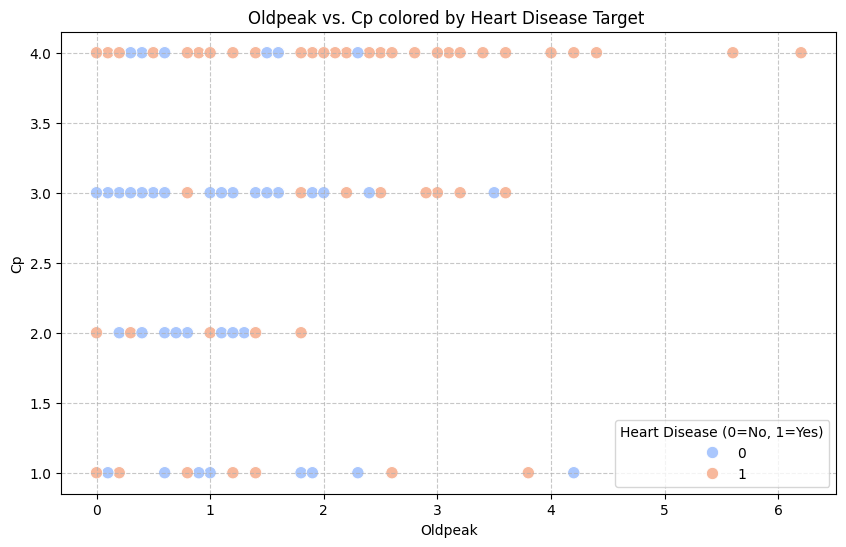

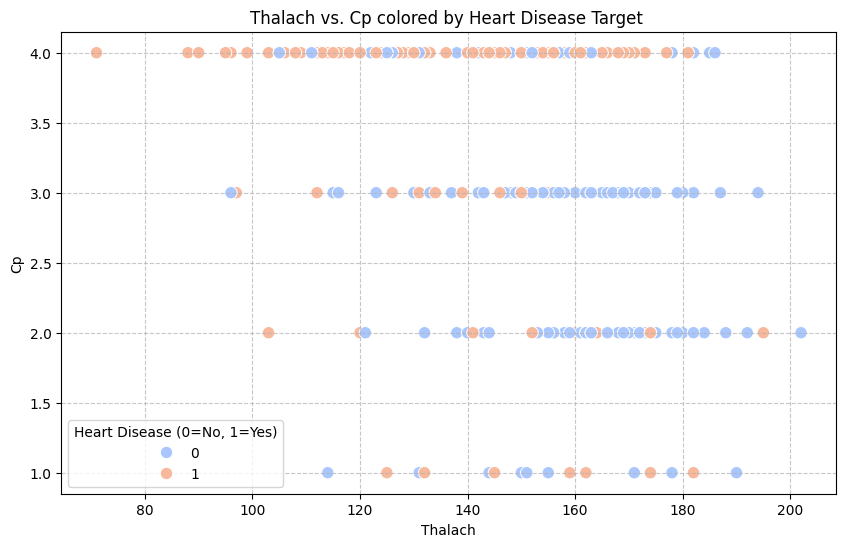

Absolute Feature correlations with target (descending order):
 thal                 0.522057
ca                   0.460033
exang                0.431894
oldpeak              0.424510
thalach              0.417167
cp                   0.414446
thalach_age_ratio    0.379745
slope                0.339213
sex                  0.276816
age                  0.223120
restecg              0.169202
trestbps             0.150825
chol                 0.085164
fbs                  0.025264
dtype: float64

Selected top 6 features by correlation with target: ['thal', 'ca', 'exang', 'oldpeak', 'thalach', 'cp']


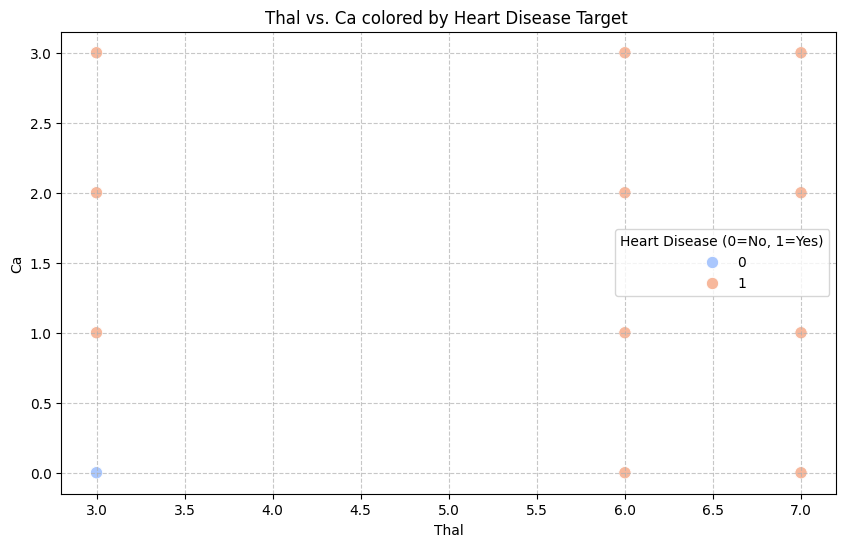

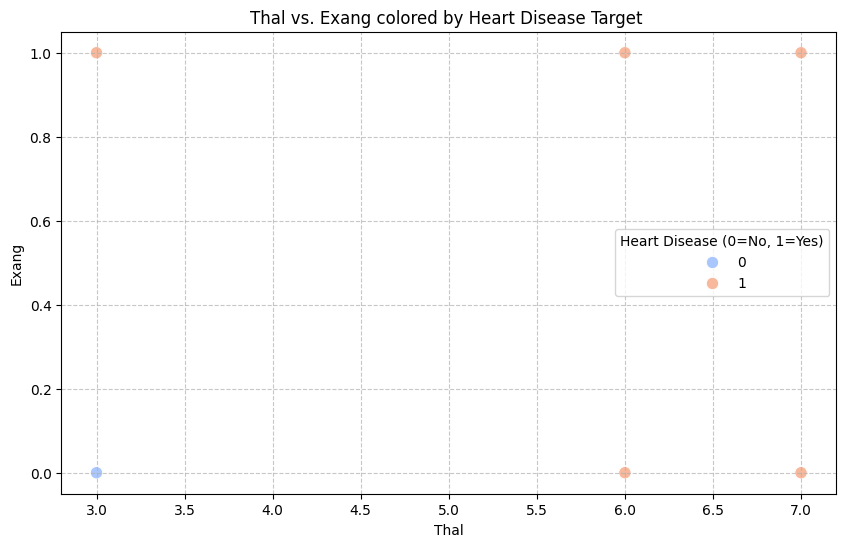

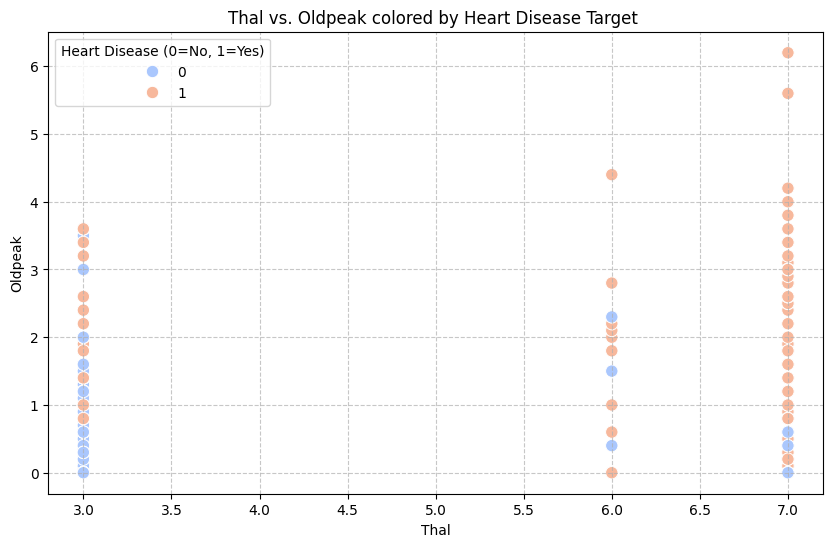

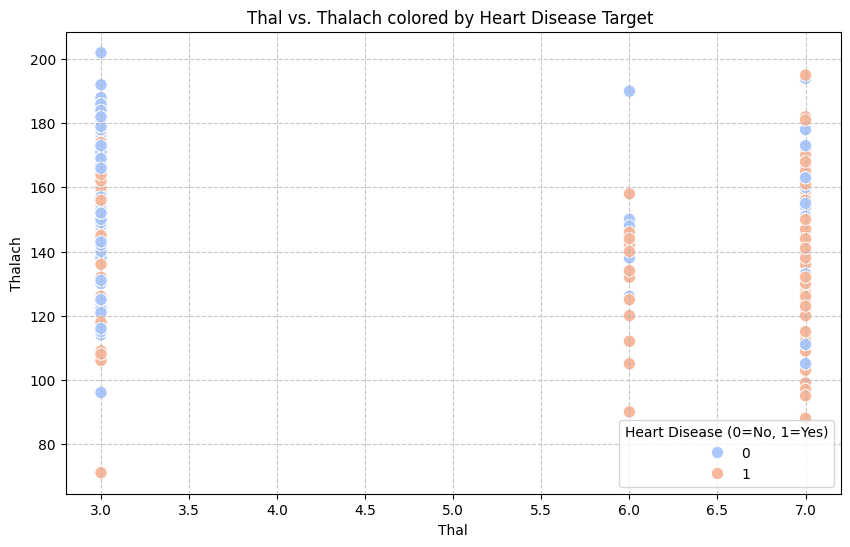

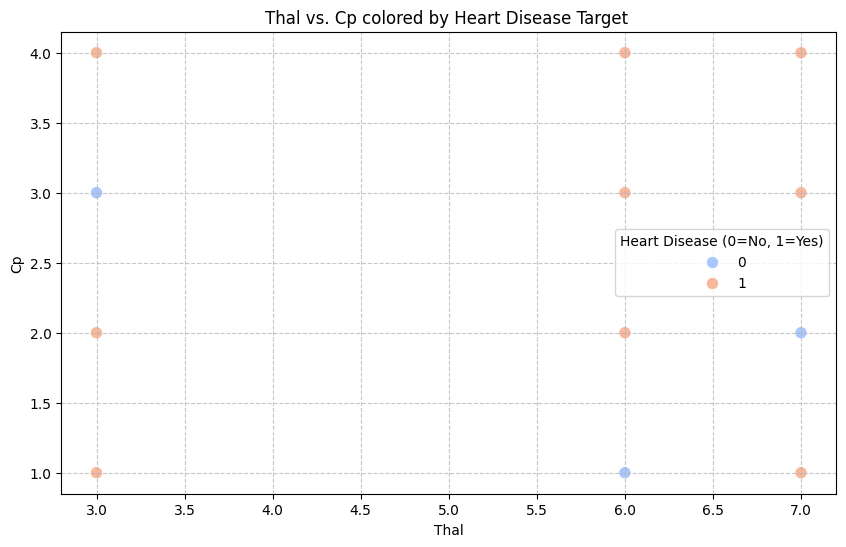

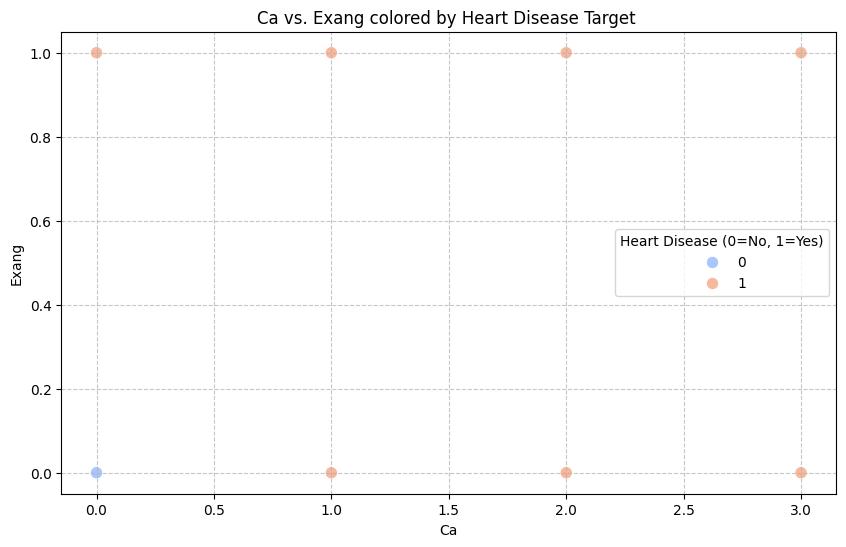

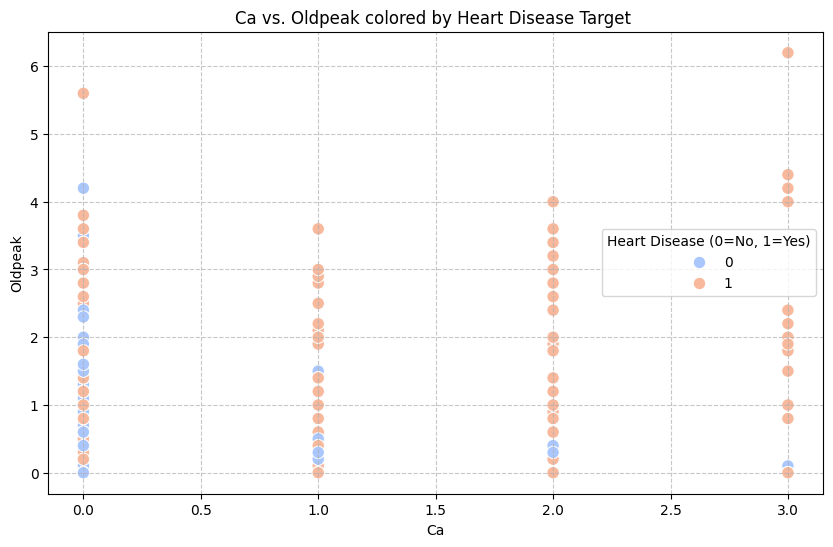

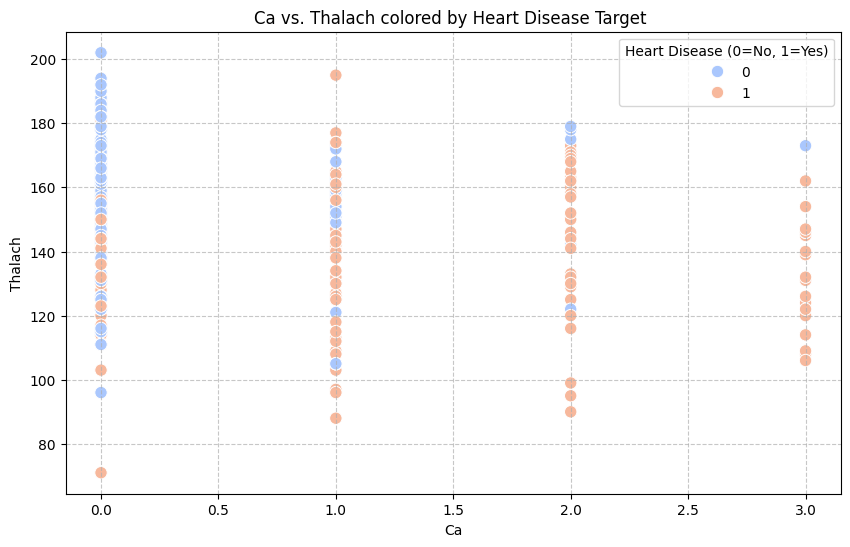

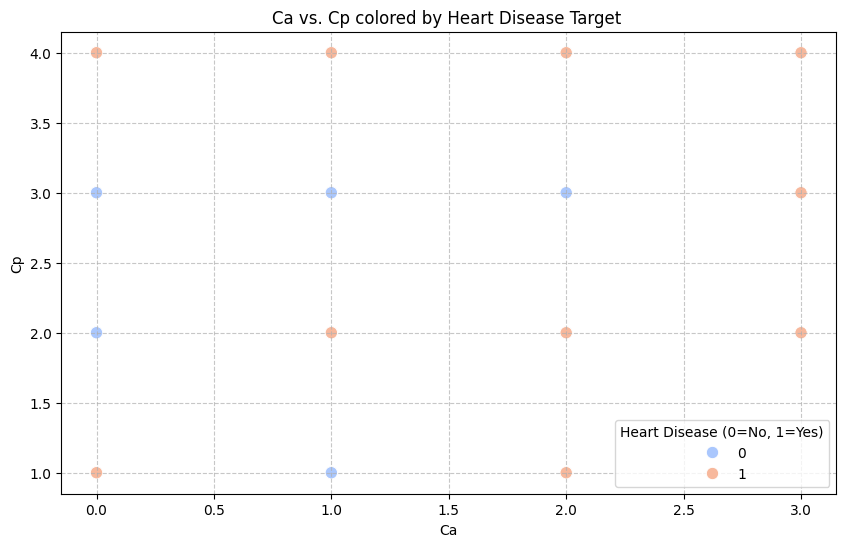

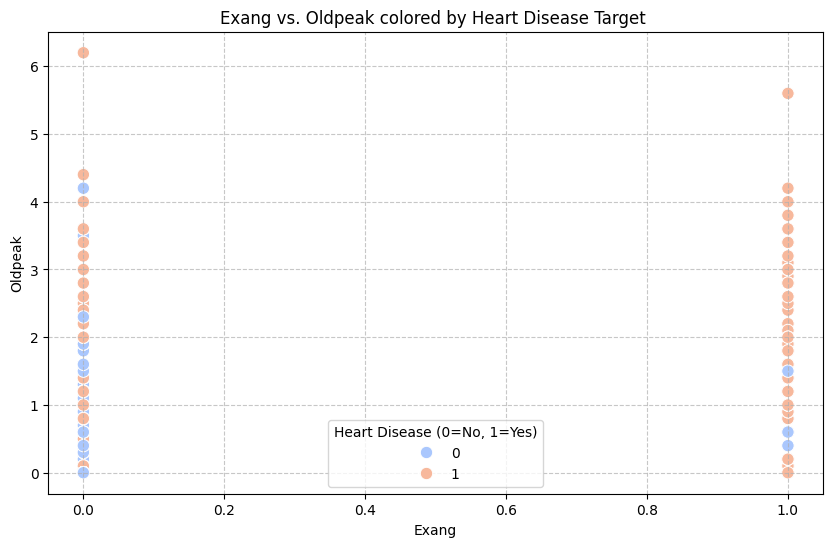

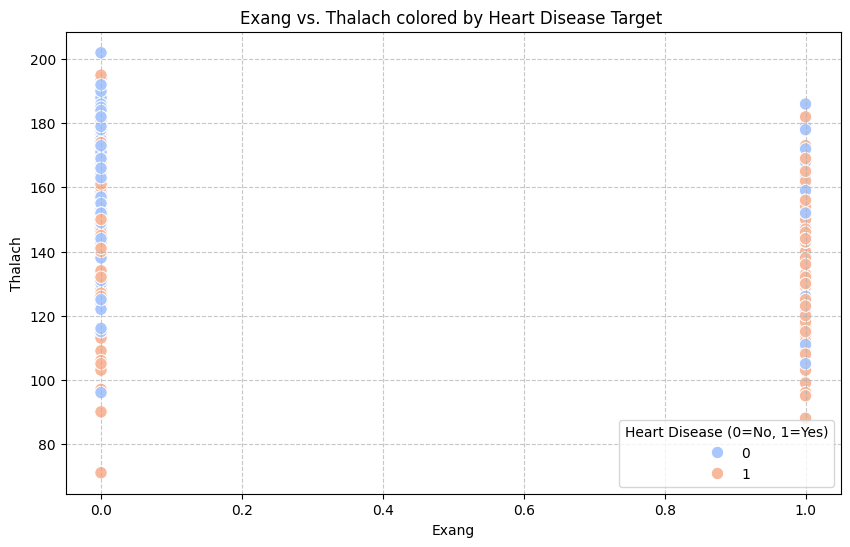

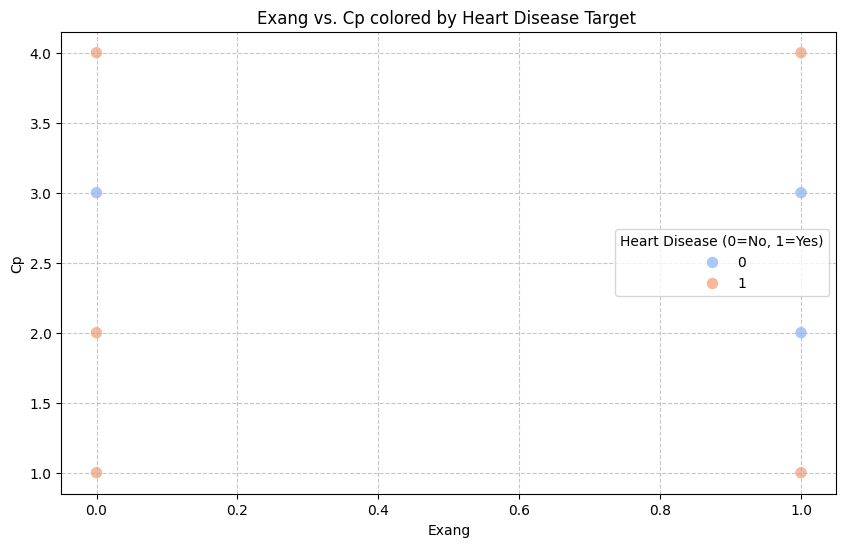

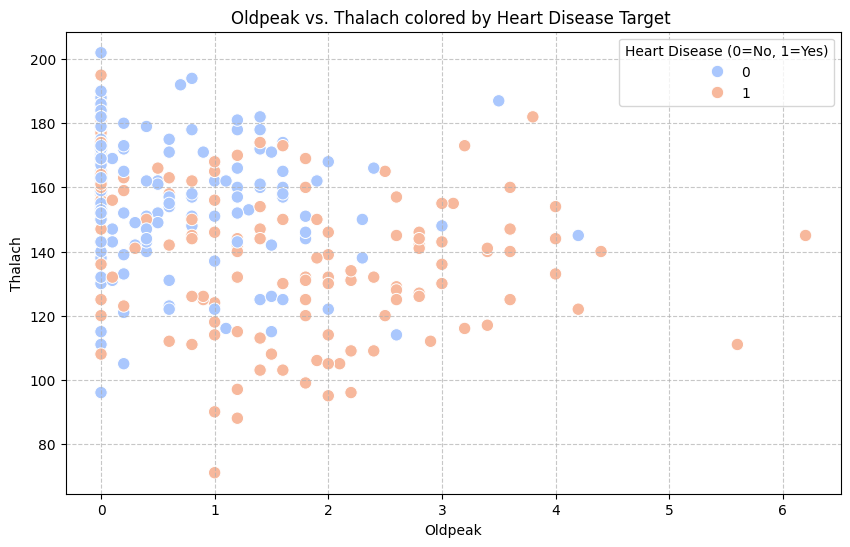

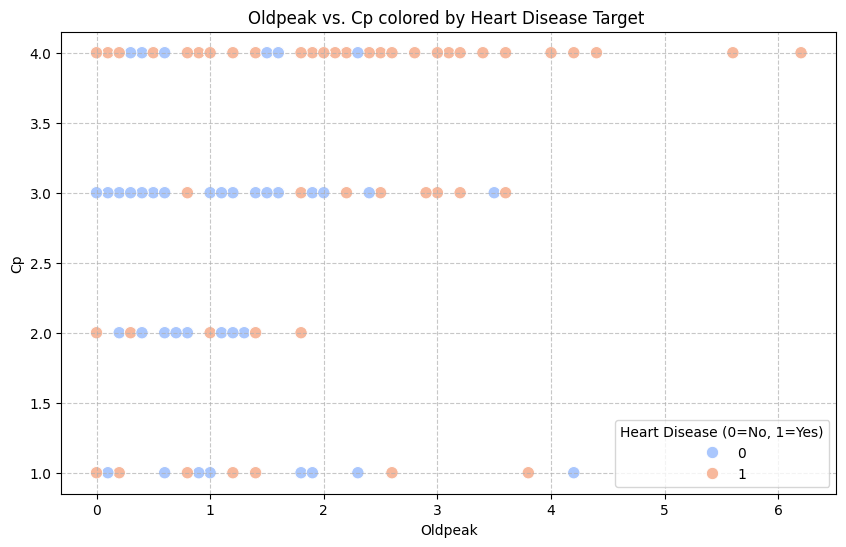

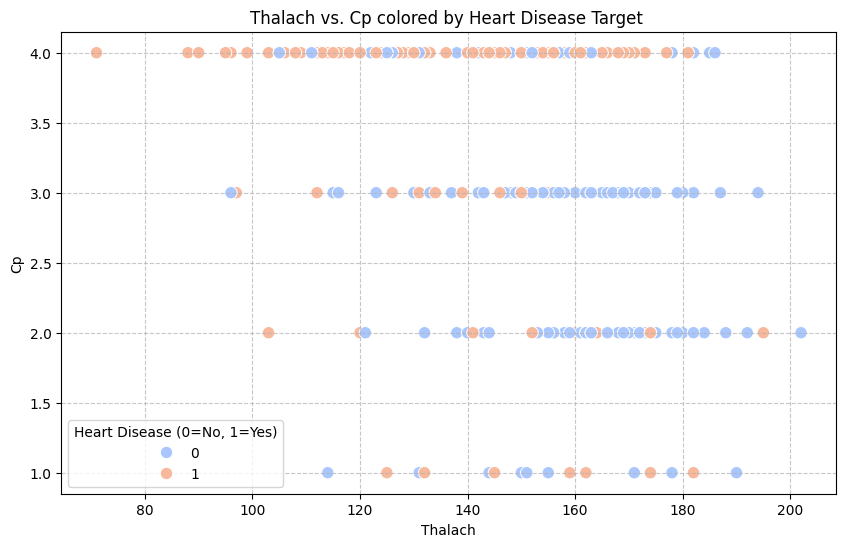

In [ ]:
X_data = df.drop(['num', 'target'], axis=1)

# Calculate absolute correlations of all features with the target variable
correlations = df[X_data.columns].corrwith(df['target']).abs().sort_values(ascending=False)
print("Absolute Feature correlations with target (descending order):\n", correlations)

# Select top N features (e.g., top 6) for more focused visualization
top_features_count = 6 # You can adjust this number
top_features = correlations.head(top_features_count).index.tolist()
print(f"\nSelected top {top_features_count} features by correlation with target: {top_features}")

# Generate scatter plots for combinations of these top features
import itertools

for col1, col2 in itertools.combinations(top_features, 2):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=col1, y=col2, hue='target', data=df, palette='coolwarm', s=80)
    plt.title(f'{col1.capitalize()} vs. {col2.capitalize()} colored by Heart Disease Target ')
    plt.xlabel(col1.capitalize())
    plt.ylabel(col2.capitalize())
    plt.legend(title='Heart Disease (0=No, 1=Yes)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

**#####**

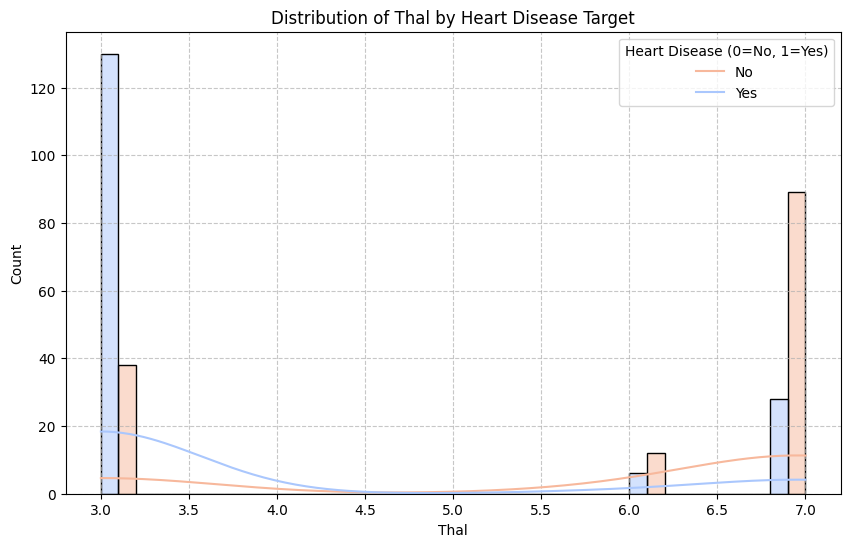

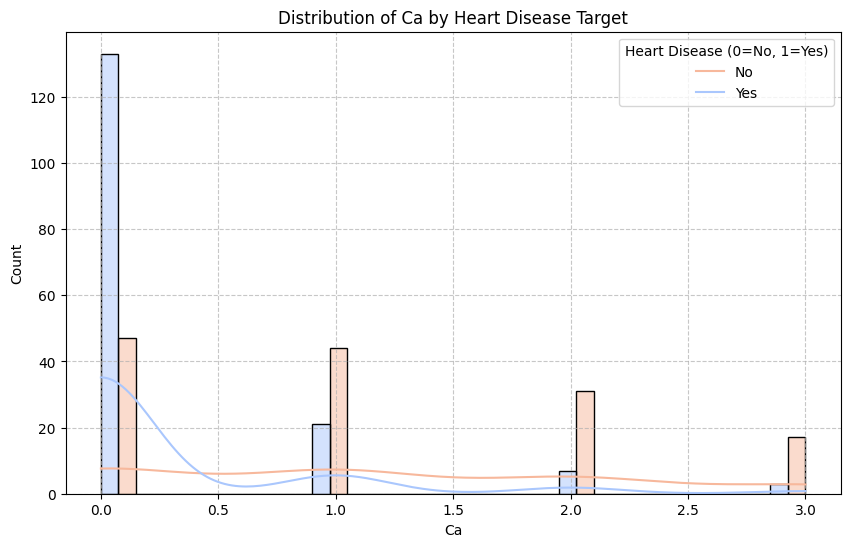

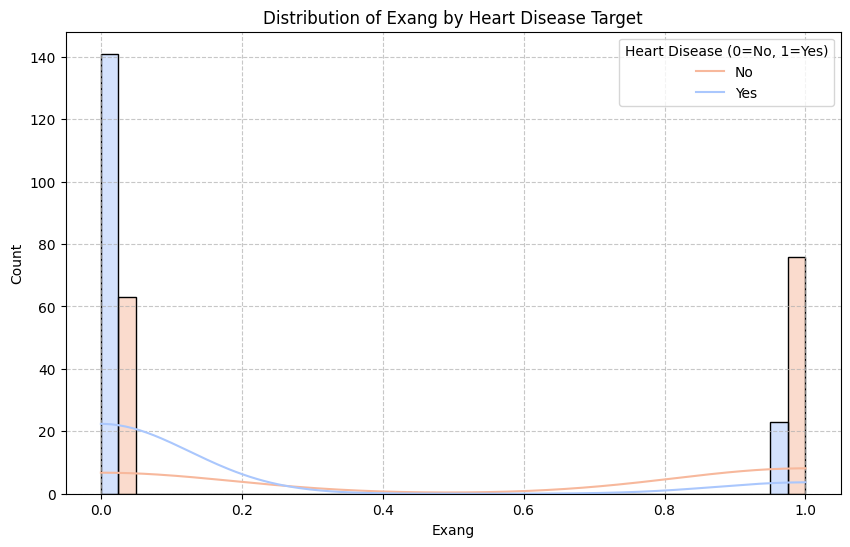

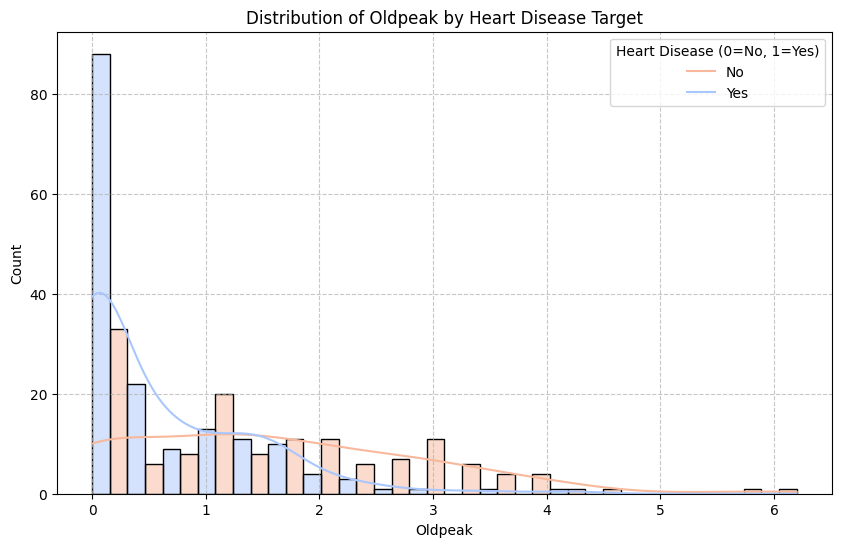

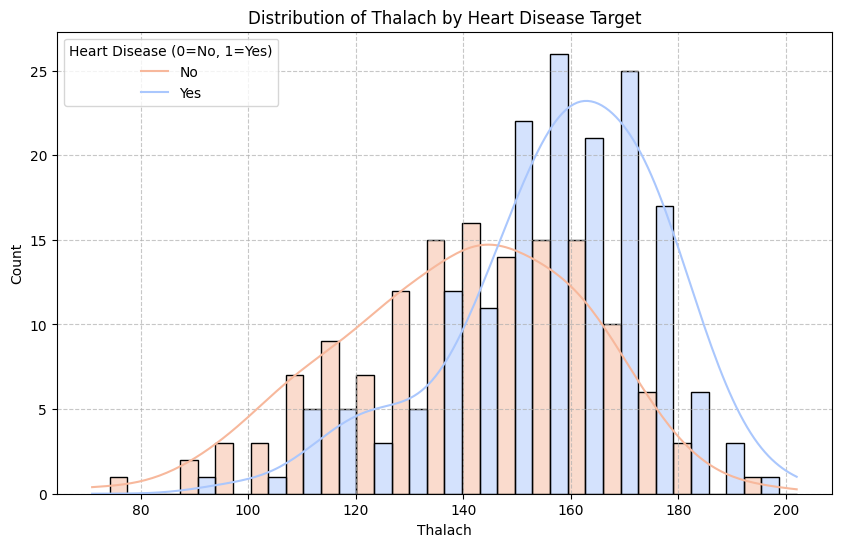

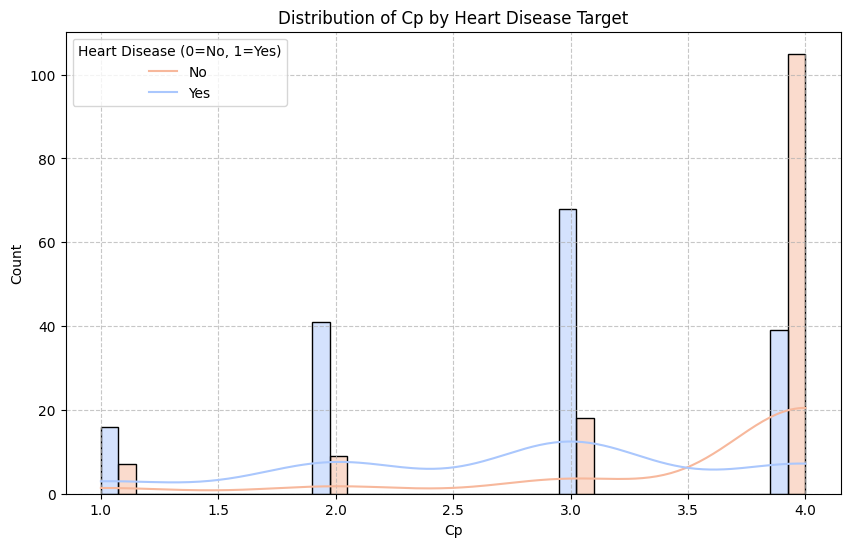

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'top_features' is already defined from the previous correlation analysis
# If not, it would need to be re-calculated:
# correlations = df[X_data.columns].corrwith(df['target']).abs().sort_values(ascending=False)
# top_features_count = 6
# top_features = correlations.head(top_features_count).index.tolist()

for feature in top_features:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=feature, hue='target', multiple='dodge', bins=20, kde=True, palette='coolwarm')
    plt.title(f'Distribution of {feature.capitalize()} by Heart Disease Target')
    plt.xlabel(feature.capitalize())
    plt.ylabel('Count')
    plt.legend(title='Heart Disease (0=No, 1=Yes)', labels=['No', 'Yes'])
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

Splitting the data into training data and testing data

In [ ]:


# Assuming X contains features and y contains labels
X_main, X_test, y_main, y_test = train_test_split(X, y, test_size=0.15, random_state=42) # 15% for testing


In [ ]:
# Split X_main and y_main, allocating a portion for validation
# Calculate the new validation size relative to the main set (e.g., for 15% validation out of original, use ~17.65% here as 0.15 / (1 - 0.15))
X_train, X_val, y_train, y_val = train_test_split(X_main, y_main, test_size=0.1765, random_state=42)


In [ ]:
# X_data = df.drop(['num', 'target'], axis=1) # Exclude original 'num' and the new 'target'
# y_data = df['target'] # Use the new binary target
# X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, stratify=y_data, random_state=42 )

In [ ]:
print (X.shape, X_train.shape, X_test.shape)
print("\n")
print("x validation: \n" , X_val, "\n\n\n--------------------\n", "y validation : \n ",y_val )
print("\n")
print(y.shape, y_train.shape, y_test.shape)

(303, 13) (211, 13) (46, 13)


x validation: 
      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
259   57    1   2       124   261    0        0      141      0      0.3   
81    53    0   4       130   264    0        2      143      0      0.4   
298   45    1   1       110   264    0        0      132      0      1.2   
287   58    1   2       125   220    0        0      144      0      0.4   
204   43    1   4       110   211    0        0      161      0      0.0   
63    54    0   3       135   304    1        0      170      0      0.0   
201   64    0   4       180   325    0        0      154      1      0.0   
30    69    0   1       140   239    0        0      151      0      1.8   
12    56    1   3       130   256    1        2      142      1      0.6   
120   48    1   4       130   256    1        2      150      1      0.0   
221   54    0   3       108   267    0        2      167      0      0.0   
16    48    1   2       110   229    0   

# **Model Training**

# **Logistic Regression**



In [ ]:
X_data = df.drop(['num', 'target'], axis=1) # Exclude original 'num' and the new 'target'
y_data = df['target'] # Use the new binary target

# Split the data after imputation
X_main, X_test, y_main, y_test = train_test_split(X_data, y_data, test_size=0.15, random_state=42) # 15% for testing
X_train, X_val, y_train, y_val = train_test_split(X_main, y_main, test_size=0.1765, random_state=42) # Remaining for train/val

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

# Model Evaluation



Accuracy score

In [ ]:
# accuracy of training data
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, y_train)

In [ ]:
print('Accuracy on training data is : ', training_data_accuracy)

Accuracy on training data is :  0.8815165876777251


In [ ]:
validation_data_accuracy_rf = model.score(X_val, y_val)
print(f'Accuracy on validation data of Logistic Regression : {validation_data_accuracy_rf:.4f}')

Accuracy on validation data of Logistic Regression : 0.7609


In [ ]:
# accuracy of test data
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, y_test)

In [ ]:
print('Accuracy on test data is : ', test_data_accuracy)

Accuracy on test data is :  0.9130434782608695


# **manual testing for Logistic Regression**


In [ ]:
# the output for this input data is 3 which was converted into binary, now represented as 1
# 57, 1, 4, 130, 131, 0, 0, 115, 1, 1.2, 2, 1.0, 7.0 -> 3 (1)
# try giving input of different values from the data set + add the thalach_age_ratio_input

# Original input_data without thalach_age_ratio
input_data_original = (57, 1, 4, 130, 131, 0, 0, 115, 1, 1.2, 2, 1.0, 7.0)

# Calculate thalach_age_ratio for the input data
age_input = input_data_original[0]
thalach_input = input_data_original[7]
thalach_age_ratio_input = thalach_input / age_input

# Create the full input_data tuple including the new feature
input_data = input_data_original + (thalach_age_ratio_input,)

input_data_as_numpy_array = np.asarray(input_data)

input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

# Convert the input array to a DataFrame with column names from X_data
input_data_df = pd.DataFrame(input_data_reshaped, columns=X_data.columns)

Prediction= model.predict(input_data_df)

print(Prediction)

if (Prediction[0]== 0):
  print('does not have Heart Disease(LR)')
else:
  print('has Heart Disease(LR)')

[1]
has Heart Disease(LR)


# Confusion Matrix for Logistic Regression (Training)

In [ ]:
cm = confusion_matrix(y_train, X_train_prediction)

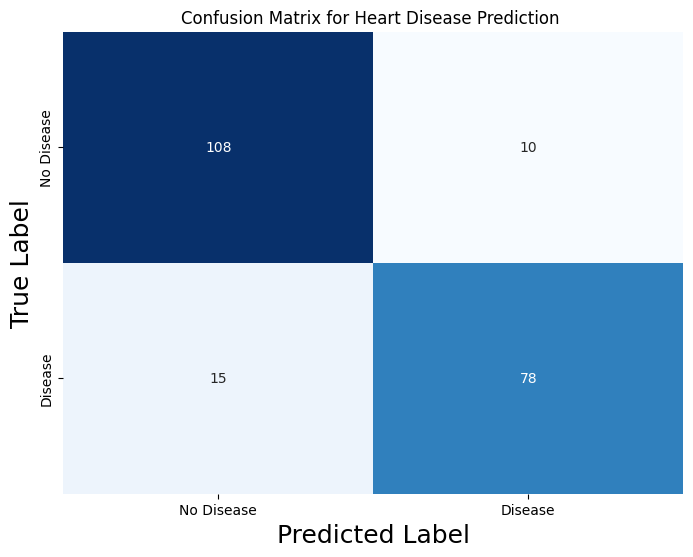

In [ ]:


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted Label', fontsize=18)
plt.ylabel('True Label',  fontsize=18)
plt.title('Confusion Matrix for Heart Disease Prediction ')
plt.show()


    True Negatives (Top-left): 108 instances were correctly predicted as 'No Disease'.
    False Positives (Top-right): 10 instances were incorrectly predicted as 'Disease' when they actually had 'No Disease'.
    False Negatives (Bottom-left): 15 instances were incorrectly predicted as 'No Disease' when they actually had 'Disease'.
    True Positives (Bottom-right): 78 instances were correctly predicted as 'Disease'.


### Confusion Matrix for Logistic Regression (Test Data)

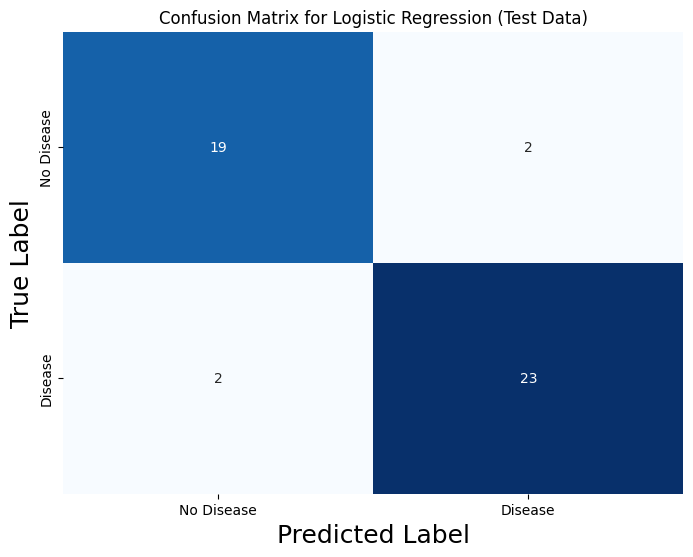

In [ ]:
y_pred_lr_test = model.predict(X_test)
cm_lr_test = confusion_matrix(y_test, y_pred_lr_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr_test, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted Label', fontsize=18)
plt.ylabel('True Label',  fontsize=18)
plt.title('Confusion Matrix for Logistic Regression (Test Data)')
plt.show()


    True Negatives (Top-left): 19 instances were correctly predicted as 'No Disease'.
    False Positives (Top-right): 2 instances were incorrectly predicted as 'Disease' when they actually had 'No Disease'.
    False Negatives (Bottom-left): 2 instances were incorrectly predicted as 'No Disease' when they actually had 'Disease'.
    True Positives (Bottom-right): 23 instances were correctly predicted as 'Disease'.




---



---


# **Random Forest**




In [ ]:
X_data = df.drop(['num', 'target'], axis=1)
y_data = df['target']

# Split the data
X_main, X_test, y_main, y_test = train_test_split(X_data, y_data, test_size=0.15, random_state=42) # 15% for testing
X_train, X_val, y_train, y_val = train_test_split(X_main, y_main, test_size=0.1765, random_state=42) # Remaining for train/val

model2 = RandomForestClassifier(n_estimators=75)
model2.fit(X_train, y_train)

RandomForestClassifier(n_estimators=75)

In [ ]:
validation_data_accuracy_rf = model2.score(X_val, y_val)
print(f'Accuracy on validation data for Random Forest: {validation_data_accuracy_rf:.4f}')

Accuracy on validation data for Random Forest: 0.6739


# Evaluation

In [ ]:
model2.score(X_test, y_test)

0.8913043478260869

### Manual testing for Random Forest Model

In [ ]:
input_data_rf_original = (67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0)

age_input_rf = input_data_rf_original[0]
thalach_input_rf = input_data_rf_original[7]
thalach_age_ratio_input_rf = thalach_input_rf / age_input_rf

input_data_rf = input_data_rf_original + (thalach_age_ratio_input_rf,)

input_data_as_numpy_array_rf = np.asarray(input_data_rf)

input_data_reshaped_rf = input_data_as_numpy_array_rf.reshape(1, -1)

# Convert the input array to a DataFrame with column names from X_data
input_data_df_rf = pd.DataFrame(input_data_reshaped_rf, columns=X_data.columns)

prediction_rf = model2.predict(input_data_df_rf)

print(prediction_rf)

if (prediction_rf[0] == 0):
  print('The patient does not have Heart Disease (RF)')
else:
  print('The patient has Heart Disease (RF)')

[1]
The patient has Heart Disease (RF)


### Confusion Matrix for Random Forest Model (Training Data)

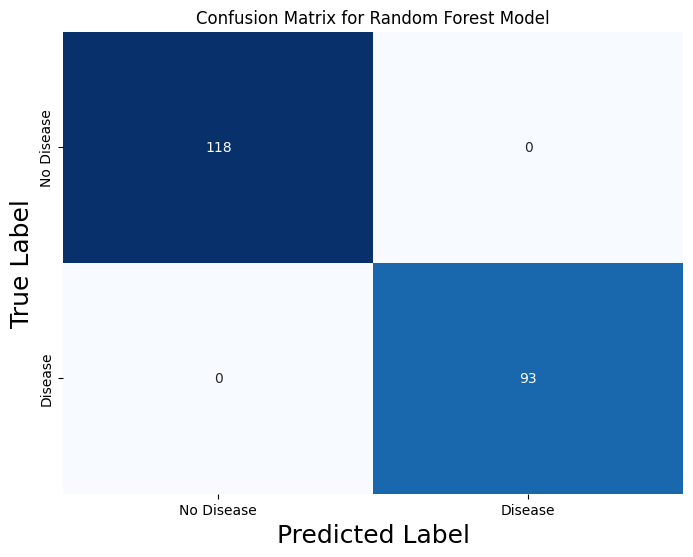

In [ ]:
X_train_prediction_rf = model2.predict(X_train)
cm_rf = confusion_matrix(y_train, X_train_prediction_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted Label', fontsize=18)
plt.ylabel('True Label', fontsize=18)
plt.title('Confusion Matrix for Random Forest Model')
plt.show()


    True Negatives (Top-left): 118 instances were correctly predicted as 'No Disease'.
    False Positives (Top-right): 0 instances were incorrectly predicted as 'Disease' when they actually had 'No Disease'.
    False Negatives (Bottom-left): 0 instances were incorrectly predicted as 'No Disease' when they actually had 'Disease'.
    True Positives (Bottom-right): 93 instances were correctly predicted as 'Disease'.


### Confusion Matrix for Random Forest (Test Data)

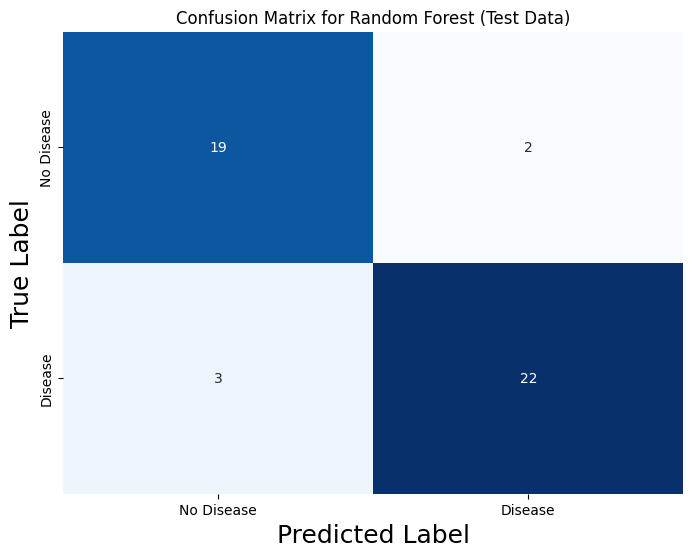

In [ ]:
y_pred_rf_test = model2.predict(X_test)
cm_rf_test = confusion_matrix(y_test, y_pred_rf_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_test, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted Label', fontsize=18)
plt.ylabel('True Label', fontsize=18)
plt.title('Confusion Matrix for Random Forest (Test Data)')
plt.show()


    True Negatives (Top-left): 19 instances were correctly predicted as 'No Disease'.
    False Positives (Top-right): 2 instances were incorrectly predicted as 'Disease' when they actually had 'No Disease'.
    False Negatives (Bottom-left): 2 instances were incorrectly predicted as 'No Disease' when they actually had 'Disease'.
    True Positives (Bottom-right): 23 instances were correctly predicted as 'Disease'.


# **KNN (K-Nearest Neighbors)**

### KNN (K-Nearest Neighbors)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier


knn_model = KNeighborsClassifier(n_neighbors=8)
knn_model.fit(X_train, y_train)


validation_data_accuracy_knn = knn_model.score(X_val, y_val)
print(f'Accuracy on validation data for KNN: {validation_data_accuracy_knn:.4f}')

Accuracy on validation data for KNN: 0.6304


### Evaluation of KNN Model

In [ ]:
# Accuracy on test data
test_data_accuracy_knn = knn_model.score(X_test, y_test)
print(f'Accuracy on test data for KNN: {test_data_accuracy_knn:.4f}')

Accuracy on test data for KNN: 0.6304


### Manual testing for KNN Model

In [ ]:
# Example input from the dataset (corresponding to a patient with heart disease)
input_data_knn_original = (67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0)

# Calculate thalach_age_ratio for the KNN input data
age_input_knn = input_data_knn_original[0]
thalach_input_knn = input_data_knn_original[7]
thalach_age_ratio_input_knn = thalach_input_knn / age_input_knn

# Create the full input_data tuple including the new feature
input_data_knn = input_data_knn_original + (thalach_age_ratio_input_knn,)

input_data_as_numpy_array_knn = np.asarray(input_data_knn)

input_data_reshaped_knn = input_data_as_numpy_array_knn.reshape(1, -1)

# Convert the input array to a DataFrame with column names from X_data
input_data_df_knn = pd.DataFrame(input_data_reshaped_knn, columns=X_data.columns)

prediction_knn = knn_model.predict(input_data_df_knn)

print(prediction_knn)

if (prediction_knn[0] == 0):
  print('The patient does not have Heart Disease (KNN)')
else:
  print('The patient has Heart Disease (KNN)')

[1]
The patient has Heart Disease (KNN)


### Confusion Matrix for KNN (Training Data)

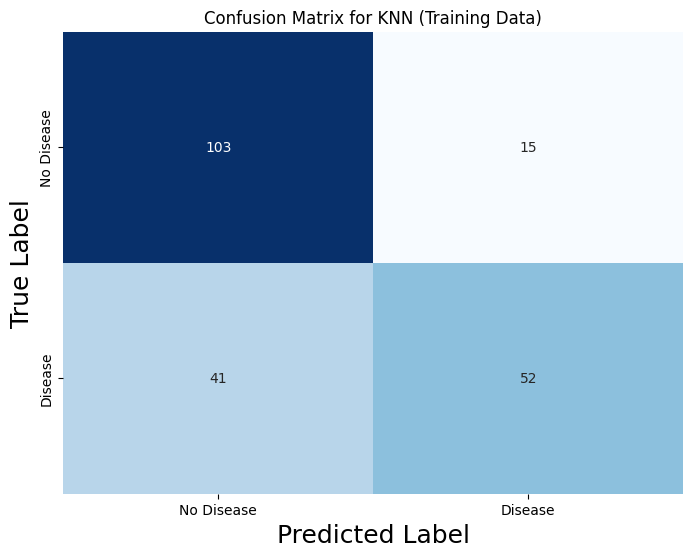

In [ ]:
X_train_prediction_knn = knn_model.predict(X_train)
cm_knn_train = confusion_matrix(y_train, X_train_prediction_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn_train, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted Label', fontsize=18)
plt.ylabel('True Label', fontsize=18)
plt.title('Confusion Matrix for KNN (Training Data)')
plt.show()

    True Negatives: Instances correctly predicted as 'No Disease'.
    False Positives: Instances incorrectly predicted as 'Disease' (Type I error).
    False Negatives: Instances incorrectly predicted as 'No Disease' (Type II error).
    True Positives: Instances correctly predicted as 'Disease'.

### Confusion Matrix for KNN (Test Data)

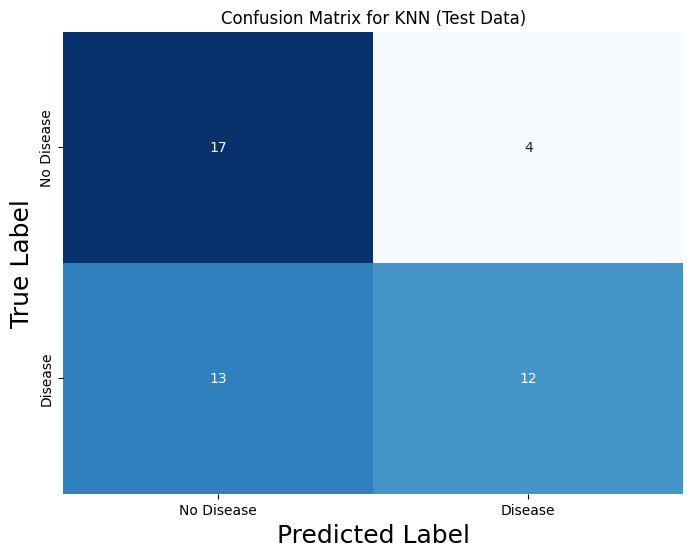

In [ ]:
y_pred_knn_test = knn_model.predict(X_test)
cm_knn_test = confusion_matrix(y_test, y_pred_knn_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn_test, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted Label', fontsize=18)
plt.ylabel('True Label', fontsize=18)
plt.title('Confusion Matrix for KNN (Test Data)')
plt.show()

    True Negatives: Instances correctly predicted as 'No Disease'.
    False Positives: Instances incorrectly predicted as 'Disease' (Type I error).
    False Negatives: Instances incorrectly predicted as 'No Disease' (Type II error).
    True Positives: Instances correctly predicted as 'Disease'.

### Model Performance Comparison

In [ ]:
# Calculate training accuracy for KNN explicitly
training_data_accuracy_knn = knn_model.score(X_train, y_train)

# Prepare data for comparison
performance_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'KNN'],
    'Training Accuracy': [training_data_accuracy, model2.score(X_train, y_train), training_data_accuracy_knn],
    'Validation Accuracy': [model.score(X_val, y_val), model2.score(X_val, y_val), validation_data_accuracy_knn],
    'Test Accuracy': [model.score(X_test, y_test), model2.score(X_test, y_test), knn_model.score(X_test, y_test)]
}

performance_df = pd.DataFrame(performance_data)

display(performance_df)

,Model,Training Accuracy,Validation Accuracy,Test Accuracy
0,Logistic Regression,0.881517,0.760870,0.913043
1,Random Forest,1.000000,0.673913,0.891304
2,KNN,0.734597,0.630435,0.630435


# **XGBoost**

In [ ]:
model_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model_xgb.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:16:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

### Evaluation of XGBoost Model

In [ ]:
# Accuracy on training data
training_data_accuracy_xgb = model_xgb.score(X_train, y_train)
print(f'Accuracy on training data for XGBoost: {training_data_accuracy_xgb:.4f}')

# Accuracy on validation data
validation_data_accuracy_xgb = model_xgb.score(X_val, y_val)
print(f'Accuracy on validation data for XGBoost: {validation_data_accuracy_xgb:.4f}')

# Accuracy on test data
test_data_accuracy_xgb = model_xgb.score(X_test, y_test)
print(f'Accuracy on test data for XGBoost: {test_data_accuracy_xgb:.4f}')

Accuracy on training data for XGBoost: 1.0000
Accuracy on validation data for XGBoost: 0.6739
Accuracy on test data for XGBoost: 0.8696


### Manual testing for XGBoost Model

In [ ]:
# Example input from the dataset (corresponding to a patient with heart disease)
input_data_xgb_original = (67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0)

# Calculate thalach_age_ratio for the XGBoost input data
age_input_xgb = input_data_xgb_original[0]
thalach_input_xgb = input_data_xgb_original[7]
thalach_age_ratio_input_xgb = thalach_input_xgb / age_input_xgb

# Create the full input_data tuple including the new feature
input_data_xgb = input_data_xgb_original + (thalach_age_ratio_input_xgb,)

input_data_as_numpy_array_xgb = np.asarray(input_data_xgb)

input_data_reshaped_xgb = input_data_as_numpy_array_xgb.reshape(1, -1)

input_data_df_xgb = pd.DataFrame(input_data_reshaped_xgb, columns=X_data.columns)

prediction_xgb = model_xgb.predict(input_data_df_xgb)

print(prediction_xgb)

if (prediction_xgb[0] == 0):
  print('The patient does not have Heart Disease (XGBoost)')
else:
  print('The patient has Heart Disease (XGBoost)')

[1]
The patient has Heart Disease (XGBoost)


### Confusion Matrix for XGBoost (Training Data)

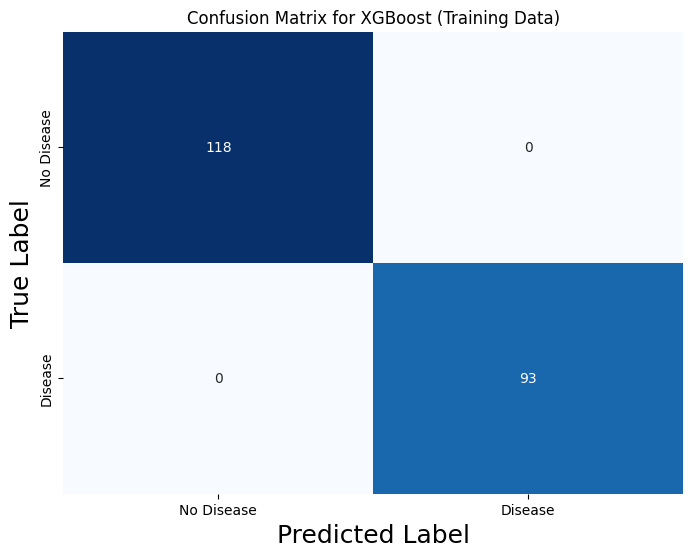

In [ ]:
X_train_prediction_xgb = model_xgb.predict(X_train)
cm_xgb_train = confusion_matrix(y_train, X_train_prediction_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb_train, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted Label', fontsize=18)
plt.ylabel('True Label', fontsize=18)
plt.title('Confusion Matrix for XGBoost (Training Data)')
plt.show()

### Confusion Matrix for XGBoost (Test Data)

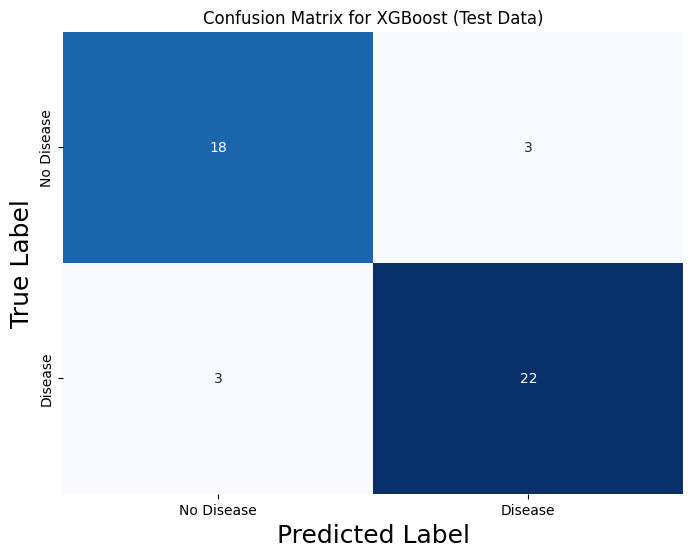

In [ ]:
y_pred_xgb_test = model_xgb.predict(X_test)
cm_xgb_test = confusion_matrix(y_test, y_pred_xgb_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb_test, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted Label', fontsize=18)
plt.ylabel('True Label', fontsize=18)
plt.title('Confusion Matrix for XGBoost (Test Data)')
plt.show()

### Update Model Performance Comparison

In [ ]:
performance_data['Model'].append('XGBoost')
performance_data['Training Accuracy'].append(model_xgb.score(X_train, y_train))
performance_data['Validation Accuracy'].append(model_xgb.score(X_val, y_val))
performance_data['Test Accuracy'].append(model_xgb.score(X_test, y_test))

performance_df = pd.DataFrame(performance_data)
display(performance_df)

,Model,Training Accuracy,Validation Accuracy,Test Accuracy
0,Logistic Regression,0.881517,0.760870,0.913043
1,Random Forest,1.000000,0.673913,0.891304
2,KNN,0.734597,0.630435,0.630435
3,XGBoost,1.000000,0.673913,0.869565
